In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import polars as pl
from math import log
import matplotlib.pyplot as plt
import gc
from ydata_profiling import ProfileReport
from sklearn.feature_selection import r_regression , f_classif
from sklearn.preprocessing import MinMaxScaler
import polars.selectors as cs

In [3]:
trips_df = pl.read_csv(source="data/trips_dataset.csv" , infer_schema_length = 10000)

individuals_df = pl.read_csv(source="data/individuals_dataset.csv" , infer_schema_length=10000)

In [4]:
trips_df.shape , individuals_df.shape

((80697, 27), (3337, 27))

In [5]:
individuals_with_trips_df = individuals_df.join(other = trips_df, on=["ID"], how ="inner" , suffix="_right" , coalesce=True)

In [6]:
individuals_with_trips_df

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
str,i64,str,str,i64,str,i64,str,i64,i64,f64,f64,i64,i64,bool,bool,i64,str,str,str,bool,bool,bool,bool,bool,f64,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-monday-44851-PDD""","""monday""","""2022-10-17""","""Normal""","""No_Trip""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,97.171946
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-1""","""tuesday""","""2022-10-18""","""Strike""","""1""","""Internal""","""SAVIGNY-SUR-ORGE""","""SAINT-MAUR-DES-FOSSES""","""91589""","""94068""","""OS""","""IS""","""2022-10-18""","""07:29:00""","""2022-10-18""","""08:41:00""",72.0,"""DEPART_HOME""","""OTHER""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-2""","""tuesday""","""2022-10-18""","""Strike""","""2""","""Internal""","""SAINT-MAUR-DES-FOSSES""","""SAINTE-GENEVIEVE-DES-BOIS""","""94068""","""91549""","""IS""","""OS""","""2022-10-18""","""10:48:00""","""2022-10-18""","""11:27:00""",39.0,"""OTHER""","""LEISURE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-3""","""tuesday""","""2022-10-18""","""Strike""","""3""","""Internal""","""SAINTE-GENEVIEVE-DES-BOIS""","""EPINAY-SUR-ORGE""","""91549""","""91216""","""OS""","""OS""","""2022-10-18""","""13:23:00""","""2022-10-18""","""13:40:00""",17.0,"""LEISURE""","""PURCHASE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""","""Woman""",45,null,2,"""In a couple with child(ren)""",4,0,0.0,2.0,2,0,false,true,3,"""2""","""4+""","""0""",false,false,false,false,false,786.094977,true,"""42_0001-tuesday-44852-4""","""tuesday""","""2022-10-18""","""Strike""","""4""","""Internal""","""EPINAY-SUR-ORGE""","""SAVIGNY-SUR-ORGE""","""91216""","""91589""","""OS""","""OS""","""2022-10-18""","""14:08:00""","""2022-10-18""","""14:14:00""",6.0,"""PURCHASE""","""RETURN_HOME""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""4_2386""",77359,"""Perthes""","""Woman""",21,null,7,"""Living with one or both parent…",6,0,3.0,1.0,2,0,false,true,3,"""2""","""0""","""0""",false,false,false,false,false,887.395126,true,"""4_2386-sunday-44955-2""","""sunday""","""2023-01-29""","""Normal""","""2""","""Internal""","""MASSY""","""PERTHES""","""91377""","""77359""","""OS""","""OS""","""2023-01-29""","""12:58:00""","""2023-01-29""","""13:34:00""",36.0,"""ACCOM""","""RETURN_HOME""","""PRIV_CAR_DRIVER""","""PRIV_CAR_DRIVER""",null,null,null,null,124.509471
"""4_2386"

In [7]:
individuals_with_trips_df.describe()

statistic,ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
str,str,f64,str,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64
"""count""","""80697""",80697.0,"""80697""","""80697""",80697.0,"""67863""",80697.0,"""80697""",80697.0,80697.0,80697.0,80697.0,80697.0,80697.0,80697.0,80364.0,80697.0,"""80697""","""80697""","""80697""",78614.0,80697.0,80697.0,80697.0,80697.0,80697.0,80697.0,"""80697""","""80697""","""80697""","""80697""","""80697""","""77002""","""76717""","""76717""","""76717""","""76717""","""76301""","""76203""","""76718""","""76696""","""76718""","""76688""",76667.0,"""76718""","""76718""","""76718""","""76648""","""8375""","""2212""","""235""","""20""",80696.0
"""null_count""","""0""",0.0,"""0""","""0""",0.0,"""12834""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,333.0,0.0,"""0""","""0""","""0""",2083.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""3695""","""3980""","""3980""","""3980""","""3980""","""4396""","""4494""","""3979""","""4001""","""3979""","""4009""",4030.0,"""3979""","""3979""","""3979""","""4049""","""72322""","""78485""","""80462""","""80677""",1.0
"""mean""",null,85852.295909,null,null,42.838036,null,3.909228,null,2.545919,0.449967,0.335849,0.27975,1.237283,0.112867,0.032715,0.85817,1.061477,null,null,null,0.519831,0.093523,0.050993,0.111516,0.01953,2690.826792,0.996295,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,24.845696,null,null,null,null,null,null,null,null,407.519873
"""std""",null,8259.760338,null,null,14.394951,null,2.03322,null,1.496899,0.856357,0.658389,0.599805,0.874884,0.401618,null,null,0.89266,null,null,null,null,null,null,null,null,2821.572783,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,27.442536,null,null,null,null,null,null,null,null,443.426629
"""min""","""10_2978""",75101.0,"""Ablis""","""Man""",16.0,"""3–4-year higher education degr…",1.0,"""Another family member in the h…",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,343.084713,0.0,"""10_2978-friday-45002-1""","""friday""","""2022-10-15""","""Bridge day""","""1""","""External""","""ABBEVILLE-LA-RIVIERE""","""ABBEVILLE-LA-RIVIERE""","""01053""","""01369""","""IS""","""IS""","""2022-05-12""","""00:00:00""","""2022-05-12""","""00:00:00""",1.0,"""ACCOM""","""ACCOM""","""BIKE""","""BIKE""","""BIKE""","""BIKE""","""BIKE""","""BIKE""",0.0
"""25%""",null,77215.0,null,null,32.0,null,2.0,null,1.0,0.0,0.0,0.0,1.0,0.0,null,null,0.0,null,null,null,null,null,null,null,null,965.907327,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,8.0,null,null,null,null,null,null,null,null,124.509471
"""50%""",null,91338.0,null,null,43.0,null,3.0,null,2.0,0.0,0.0,0.0,1.0,0.0,null,null,1.0,null,null,null,null,null,null,null,null,1708.918352,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,16.0,null,null,null,null,null,null,null,null,256.714372
"""75%""",null,93051.0,null,null,53.0,null,6.0,null,4.0,1.0,0.0,0.0,2.0,0.0,null,null,2.0,null,null,null,null,null,null,null,null,3070.14298,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,32.0,null,null,null,null,null,null,null,null,462.750015
"""max""","""7_2976""",95680.0,"""Yerres""","""Woman""",82.0,"""Vocational certificate (CAP, B…",8.0,"""Single parent (divorced / sepa…",12.0,4.0,4.0,4.0,4.0,4.0,1.0,1.0,8.0,"""4+""",""

In [8]:
individuals_with_trips_df.null_count()

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,12834,0,0,0,0,0,0,0,0,0,333,0,0,0,0,2083,0,0,0,0,0,0,0,0,0,0,0,3695,3980,3980,3980,3980,4396,4494,3979,4001,3979,4009,4030,3979,3979,3979,4049,72322,78485,80462,80677,1


In [9]:
dtypes_dict = {col: individuals_with_trips_df[col].dtype for col in individuals_with_trips_df.columns}
dtypes_dict


{'ID': String,
 'CODGEO': Int64,
 'AREA_NAME': String,
 'SEX': String,
 'AGE': Int64,
 'DIPLOMA': String,
 'PRO_CAT': Int64,
 'TYPE_HOUSE': String,
 'NBPERS_HOUSE': Int64,
 'NB_10': Int64,
 'NB_11_17': Float64,
 'NB_18_24': Float64,
 'NB_25_64': Int64,
 'NB_65': Int64,
 'PMR': Boolean,
 'DRIVING_LICENCE': Boolean,
 'NB_CAR': Int64,
 'TWO_WHEELER': String,
 'BIKE': String,
 'ELECT_SCOOTER': String,
 'NAVIGO_SUB': Boolean,
 'IMAGINER_SUB': Boolean,
 'OTHER_SUB_PT': Boolean,
 'BIKE_SUB': Boolean,
 'NSM_SUB': Boolean,
 'WEIGHT_INDIV': Float64,
 'GPS_RECORD': Boolean,
 'KEY': String,
 'Day_EMG': String,
 'Date_EMG': String,
 'Day_Type': String,
 'ID_Trip_Days': String,
 'Type_Trip_OD': String,
 'Area_O': String,
 'Area_D': String,
 'Code_INSEE_O': String,
 'Code_INSEE_D': String,
 'Zone_O': String,
 'Zone_D': String,
 'Date_O': String,
 'Time_O': String,
 'Date_D': String,
 'Time_D': String,
 'Duration': Float64,
 'Purpose_O': String,
 'Purpose_D': String,
 'Main_Mode': String,
 'Mode_1': S

In [10]:
individuals_with_trips_df.filter(pl.col("GPS_RECORD") == False).height/individuals_with_trips_df.shape[0]/100


3.705218285685961e-05

In [11]:
individuals_with_trips_df = individuals_with_trips_df.filter(pl.col("GPS_RECORD") == True)

individuals_with_trips_df = individuals_with_trips_df.with_columns([
    pl.col("Date_EMG").str.to_date(strict=False),
    pl.col("Date_O").str.to_date(strict=False),
    pl.col("Date_D").str.to_date(strict=False),
    pl.col("Time_O").str.to_time(strict=False),
    pl.col("Time_D").str.to_time(strict=False),
    ]
)

## Encoding Values & Preparing Values for building model vulnerability index

### Converting Values to be ready for calculations

In [12]:
"""

for col in are_correlated.select(cs.string()):
        print(col.name ,"  ---------->  " , col.n_unique())

#OUTPUT:
    SEX   ---------->   2
    DIPLOMA   ---------->   7
    TWO_WHEELER   ---------->   5
    BIKE   ---------->   5
    ELECT_SCOOTER   ---------->   5

"""
individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
    pl.col("SEX").replace({"Man":0 , "Woman":1} ,return_dtype=pl.Int8),

    pl.col("DIPLOMA").replace({
    "5-year-and-above higher education degree: Master's 2, DEA, DESS, Grande École Diploma, Doctorate, etc.": 6,
    "3–4-year higher education degree: Licence, Professional Licence, Master 1, or equivalent": 5,
    "Upper secondary diploma (Baccalauréat) or equivalent": 4,
    "Vocational certificate (CAP, BEP) or equivalent": 3,
    "Lower secondary certificate (Brevet) or equivalent": 2,
    "No diploma": 1

                        },default=0).cast(pl.Int8),

    pl.col("TWO_WHEELER").replace({"4+":4}, return_dtype=pl.Int8),
    pl.col("BIKE").replace({"4+":4}, return_dtype=pl.Int8),
    pl.col("ELECT_SCOOTER").replace({"4+":4}, return_dtype=pl.Int8),



    ]
)

### Applying the decreasing function 1/1+log(x) according to the described relations bet. the features applied on it & the Social Vulnerability Index

In [13]:
individuals_with_trips_df = individuals_with_trips_df.with_columns([
    pl.col("NB_CAR").map_elements(lambda x : 1/1+log(1+x)), #added the 1 in the log to avoid the people with no cars
    pl.col("PRO_CAT").map_elements(lambda x : 1/1+log(x)),
    pl.col("NBPERS_HOUSE").map_elements(lambda x : 1/1+log(x)),
    pl.col("TWO_WHEELER").map_elements(lambda x : 1/1+log(1+x)),
    pl.col("BIKE").map_elements(lambda x : 1/1+log(1+x)),
    pl.col("ELECT_SCOOTER").map_elements(lambda x : 1/1+log(1+x)),
    pl.col("DIPLOMA").map_elements(lambda x : 1/1+log(1+x)),


])

### Converting Bool Values to Integers

In [14]:
individuals_with_trips_df.cast(dtypes={pl.Boolean:pl.Int8})

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,KEY,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
str,i64,str,i8,i64,f64,f64,str,f64,i64,f64,f64,i64,i64,i8,i8,f64,f64,f64,f64,i8,i8,i8,i8,i8,f64,i8,str,str,date,str,str,str,str,str,str,str,str,str,date,time,date,time,f64,str,str,str,str,str,str,str,str,f64
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,1.0,1.693147,"""In a couple with child(ren)""",2.386294,0,0.0,2.0,2,0,0,1,2.386294,2.098612,2.609438,1.0,0,0,0,0,0,786.094977,1,"""42_0001-monday-44851-PDD""","""monday""",2022-10-17,"""Normal""","""No_Trip""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,97.171946
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,1.0,1.693147,"""In a couple with child(ren)""",2.386294,0,0.0,2.0,2,0,0,1,2.386294,2.098612,2.609438,1.0,0,0,0,0,0,786.094977,1,"""42_0001-tuesday-44852-1""","""tuesday""",2022-10-18,"""Strike""","""1""","""Internal""","""SAVIGNY-SUR-ORGE""","""SAINT-MAUR-DES-FOSSES""","""91589""","""94068""","""OS""","""IS""",2022-10-18,07:29:00,2022-10-18,08:41:00,72.0,"""DEPART_HOME""","""OTHER""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,1.0,1.693147,"""In a couple with child(ren)""",2.386294,0,0.0,2.0,2,0,0,1,2.386294,2.098612,2.609438,1.0,0,0,0,0,0,786.094977,1,"""42_0001-tuesday-44852-2""","""tuesday""",2022-10-18,"""Strike""","""2""","""Internal""","""SAINT-MAUR-DES-FOSSES""","""SAINTE-GENEVIEVE-DES-BOIS""","""94068""","""91549""","""IS""","""OS""",2022-10-18,10:48:00,2022-10-18,11:27:00,39.0,"""OTHER""","""LEISURE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,1.0,1.693147,"""In a couple with child(ren)""",2.386294,0,0.0,2.0,2,0,0,1,2.386294,2.098612,2.609438,1.0,0,0,0,0,0,786.094977,1,"""42_0001-tuesday-44852-3""","""tuesday""",2022-10-18,"""Strike""","""3""","""Internal""","""SAINTE-GENEVIEVE-DES-BOIS""","""EPINAY-SUR-ORGE""","""91549""","""91216""","""OS""","""OS""",2022-10-18,13:23:00,2022-10-18,13:40:00,17.0,"""LEISURE""","""PURCHASE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001""",91589,"""Savigny-sur-Orge""",1,45,1.0,1.693147,"""In a couple with child(ren)""",2.386294,0,0.0,2.0,2,0,0,1,2.386294,2.098612,2.609438,1.0,0,0,0,0,0,786.094977,1,"""42_0001-tuesday-44852-4""","""tuesday""",2022-10-18,"""Strike""","""4""","""Internal""","""EPINAY-SUR-ORGE""","""SAVIGNY-SUR-ORGE""","""91216""","""91589""","""OS""","""OS""",2022-10-18,14:08:00,2022-10-18,14:14:00,6.0,"""PURCHASE""","""RETURN_HOME""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""4_2386""",77359,"""Perthes""",1,21,1.0,2.94591,"""Living with one or both parent…",2.791759,0,3.0,1.0,2,0,0,1,2.386294,2.098612,1.0,1.0,0,0,0,0,0,887.395126,1,"""4_2386-sunday-44955-2""","""sunday""",2023-01-29,"""Normal""","""2""","""Internal""","""MASSY""","""PERTHES""","""91377""","""77359""","""OS""","""OS""",2023-01-29,12:58:00,2023-01-29,13:34:00,36.0,"""ACCOM""","""RETURN_HOME""","""PRIV_CAR_DRIVER""","""PRIV_CAR_DRIVER""",null,null,null,null,124.509471
"""4_2386""",77359,"""Perthes""",1,21,1.0,2.94591,"""Living with one or both parent…",2.791759,0,3.0,1.0,2,0,0,1,2.386294,2.098612,1.0,1.0,0,0,0,0,0,887.395126,1,"""4_2386-sunday-44955-3""","""sunday""",2023-01-29,"""Normal""","""3""","""Internal""","""PERTHES""","""MELUN""","""77359""","""77288""","""OS""","""OS""",202

## Extensive Data Analysis

In [15]:
# ProfileReport(individuals_with_trips_df.to_pandas(),minimal=False , tsmode=False, title="Profiling Report" , explorative=True).to_file("report_after_encoding.html")


In [16]:
are_correlated = individuals_with_trips_df.select(
    pl.col(
        "SEX" , "AGE", "DIPLOMA", "PRO_CAT", "NB_CAR" , "PMR" , "NBPERS_HOUSE" ,
        "TWO_WHEELER", "BIKE", "ELECT_SCOOTER",
        "NAVIGO_SUB", "IMAGINER_SUB", "OTHER_SUB_PT" , "BIKE_SUB", "NSM_SUB"
        )
)

are_correlated.describe()

statistic,SEX,AGE,DIPLOMA,PRO_CAT,NB_CAR,PMR,NBPERS_HOUSE,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,78315.0,80398.0,80398.0,80398.0,80398.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2083.0,0.0,0.0,0.0,0.0
"""mean""",0.550138,42.846178,2.488596,2.223134,1.626139,0.03275,1.760644,1.068418,1.640529,1.069304,0.519888,0.093709,0.050959,0.111558,0.019602
"""std""",0.497483,14.387585,0.682856,0.540607,0.450863,null,0.601321,0.22566,0.619302,0.220383,null,null,null,null,null
"""min""",0.0,16.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,32.0,2.609438,1.693147,1.0,null,1.0,1.0,1.0,1.0,null,null,null,null,null
"""50%""",1.0,43.0,2.791759,2.098612,1.693147,null,1.693147,1.0,1.693147,1.0,null,null,null,null,null
"""75%""",1.0,53.0,2.94591,2.791759,2.098612,null,2.386294,1.0,2.098612,1.0,null,null,null,null,null
"""max""",1.0,82.0,2.94591,3.079442,3.197225,1.0,3.484907,2.609438,2.609438,2.609438,1.0,1.0,1.0,1.0,1.0


In [17]:
"""Indicator Group	Variable(s) from Dataset	What It Measures (Proxy for...)
Physical Capacity	PMR, AGE	Direct physical barriers to mobility
Household Resources	NB_CAR, DRIVING_LICENCE, TWO_WHEELER etc.	Access to private, independent transport options
Household Constraints	NBPERS_HOUSE, NB_10, etc.	Presence of dependents complicating evacuation
Socio-Economic Status	DIPLOMA, PRO_CAT	Income, job flexibility, information access
System Dependency	NAVIGO_SUB, etc.	Reliance on public systems that might fail
"""

'Indicator Group\tVariable(s) from Dataset\tWhat It Measures (Proxy for...)\nPhysical Capacity\tPMR, AGE\tDirect physical barriers to mobility\nHousehold Resources\tNB_CAR, DRIVING_LICENCE, TWO_WHEELER etc.\tAccess to private, independent transport options\nHousehold Constraints\tNBPERS_HOUSE, NB_10, etc.\tPresence of dependents complicating evacuation\nSocio-Economic Status\tDIPLOMA, PRO_CAT\tIncome, job flexibility, information access\nSystem Dependency\tNAVIGO_SUB, etc.\tReliance on public systems that might fail\n'

## Making It Ready to Build SVI (Social Vulnerability Index)

### Transforming AGE to be reletable to MVI based on FLANGHAN & Cutter Papers

In [18]:
mean_age = round(are_correlated["AGE"].mean())
are_correlated = are_correlated.with_columns(
    [
    pl.col("AGE").map_elements(lambda
                                   x:  log(1+abs(x-mean_age))

                               ).alias('TRANSFORMED_AGE'),
    ]
)


cols_2_continue_operations_on = are_correlated.columns
cols_2_continue_operations_on.remove("AGE")

### Normalizing All Features separately by min_max scaler to make each of them particicpate equally in the MVI

In [19]:
for col in cols_2_continue_operations_on:
    scaler = MinMaxScaler()

    scaled_values = scaler.fit_transform(X=are_correlated[col].to_numpy().reshape(-1, 1))

    are_correlated = are_correlated.with_columns(
        pl.Series(col, scaled_values.flatten(), dtype=pl.Float64)
    )

## Building the MVI

### Normalizing all Features bet. 0 & 1 to make all features particicpate equally in building the SVI

In [20]:
for col in cols_2_continue_operations_on:
    scaler = MinMaxScaler()

    scaled_values = scaler.fit_transform(X=are_correlated[col].to_numpy().reshape(-1, 1))

    are_correlated = are_correlated.with_columns(
        pl.Series(col, scaled_values.flatten(), dtype=pl.Float64)
    )

In [21]:
are_correlated = are_correlated.with_columns(sum=pl.sum_horizontal(cols_2_continue_operations_on))

are_correlated = are_correlated.rename({"sum":"MVI_raw"})




In [22]:
are_correlated["MVI_raw"].value_counts()

MVI_raw,count
f64,u32
2.734221,23
5.092079,29
5.118198,32
4.501248,32
3.140921,19
…,…
3.882793,46
4.277449,36
4.681892,24


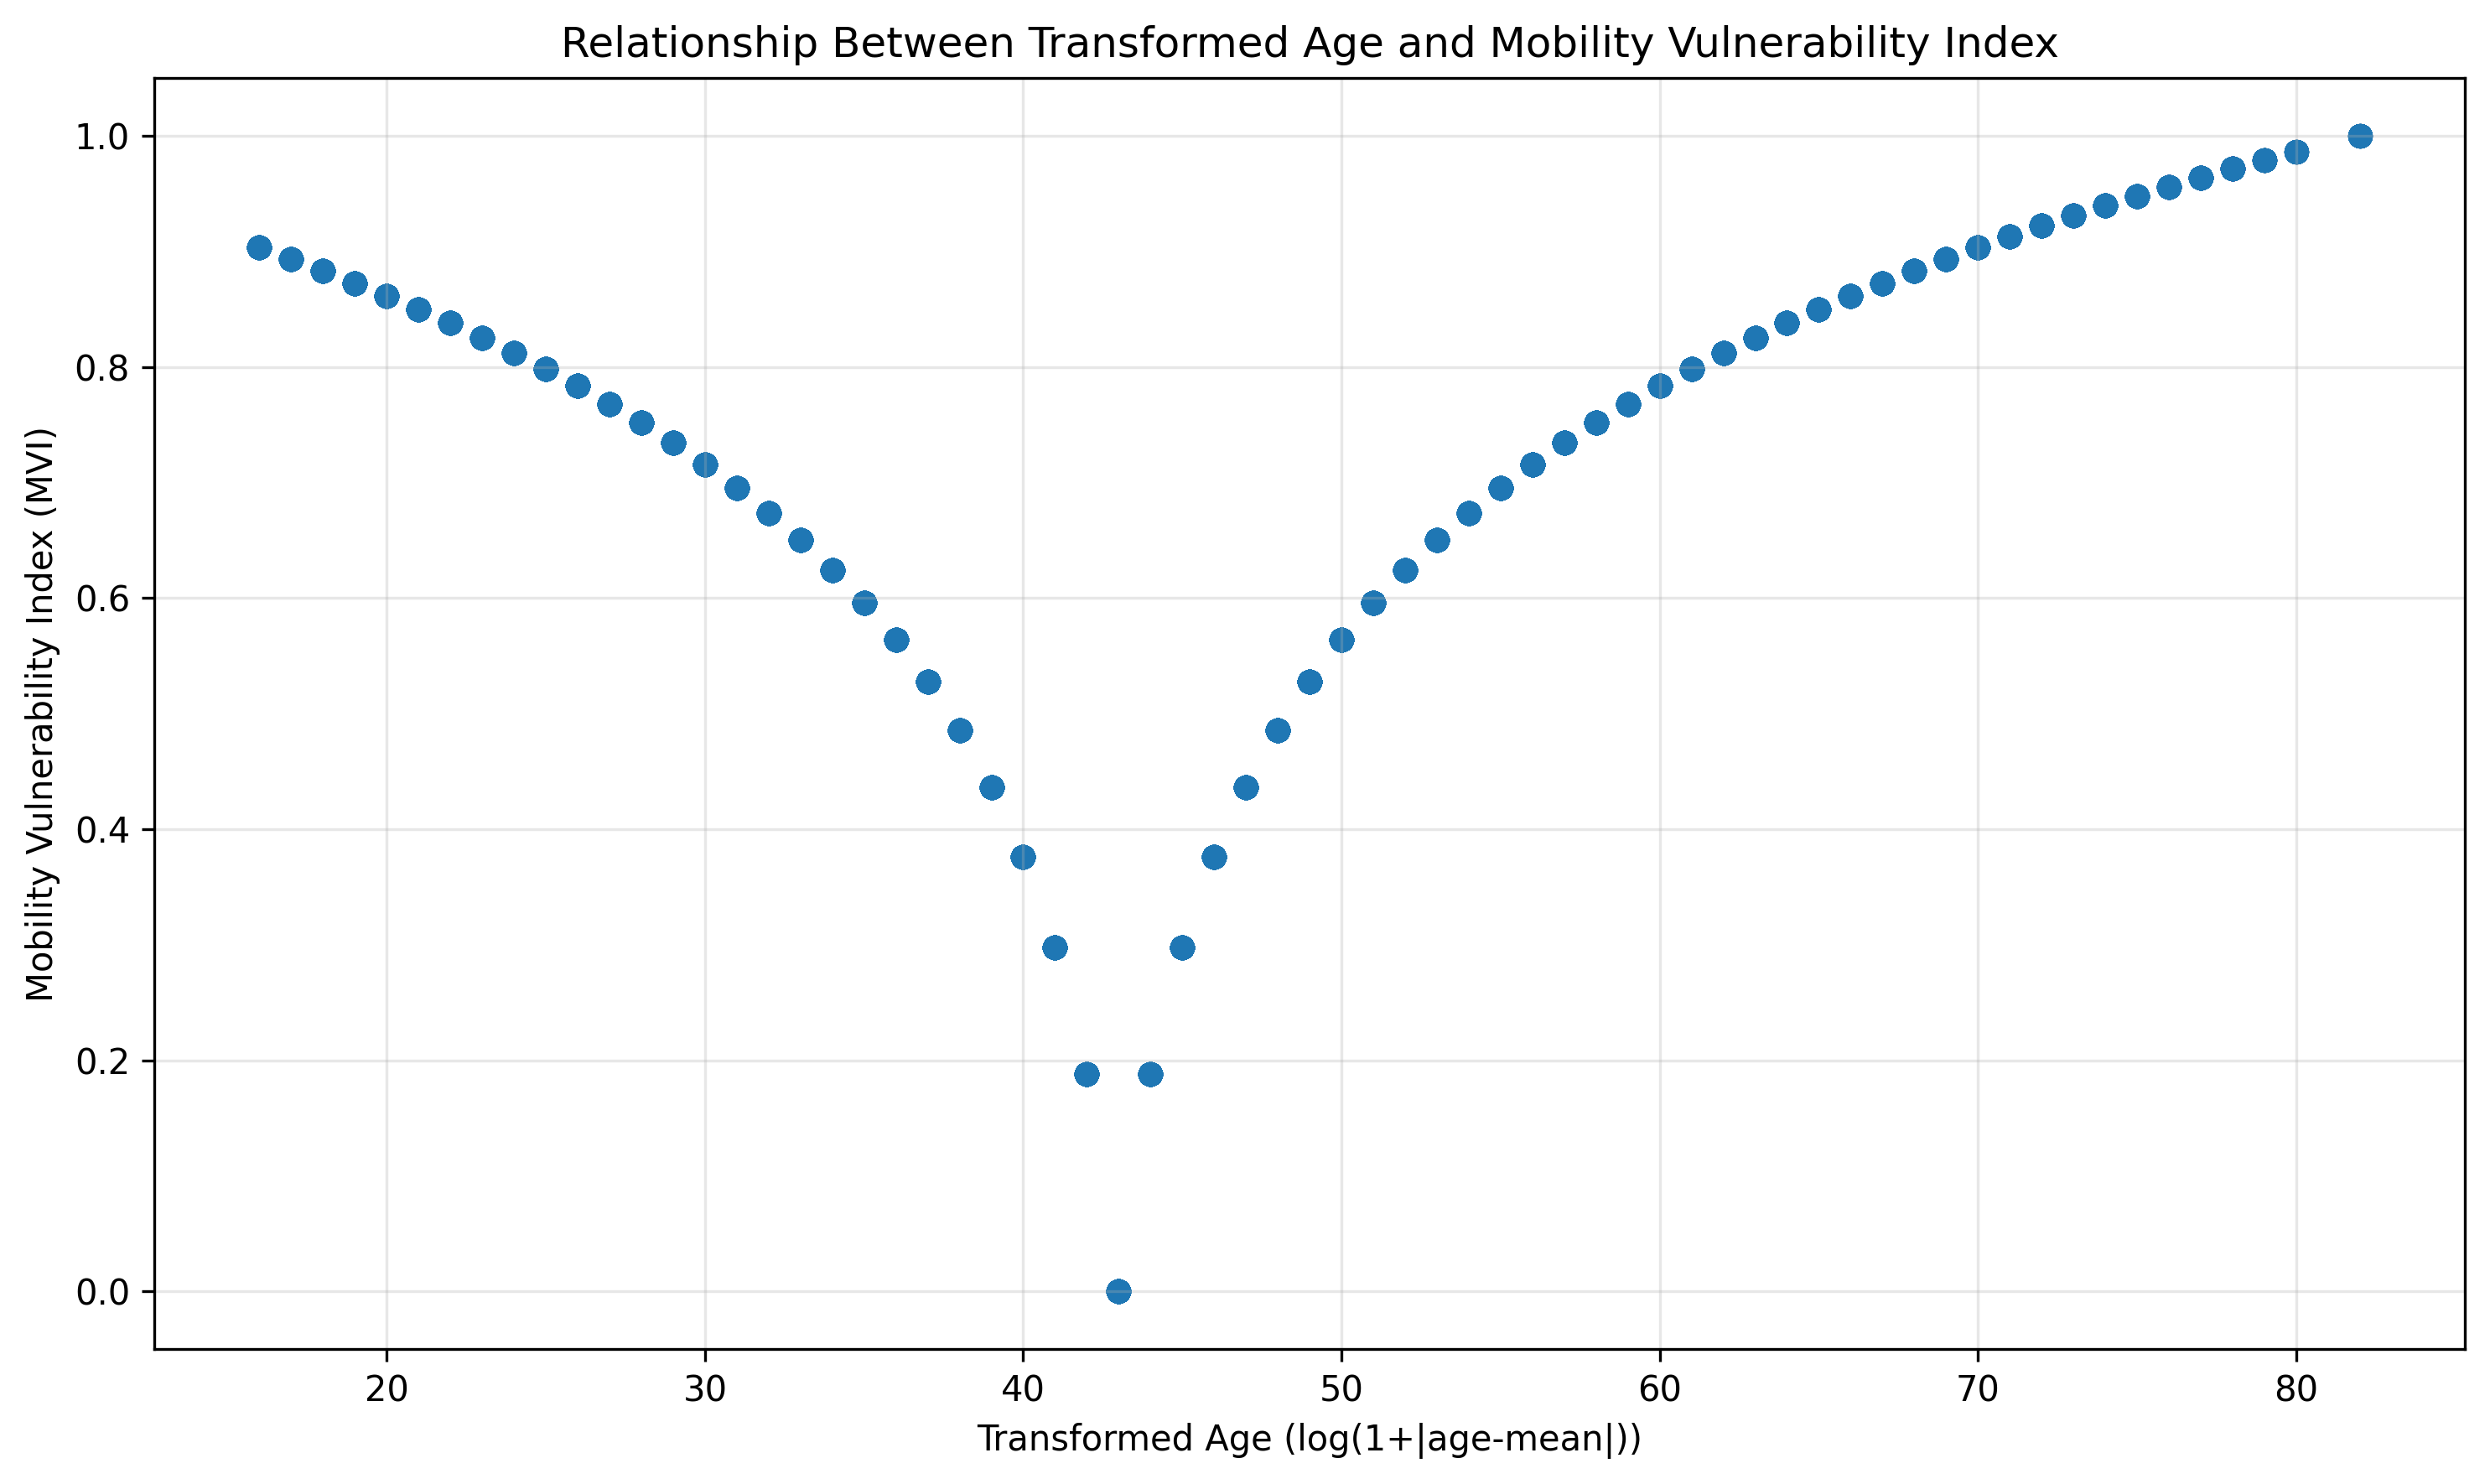

<Figure size 640x480 with 0 Axes>

In [23]:
# Create a more informative scatter plot
plt.figure(figsize=(10, 6) , dpi=300)
plt.scatter(x=are_correlated["AGE"], y=are_correlated["TRANSFORMED_AGE"], alpha=0.6)
plt.title('Relationship Between Transformed Age and Mobility Vulnerability Index')
plt.xlabel('Transformed Age (log(1+|age-mean|))')
plt.ylabel('Mobility Vulnerability Index (MVI)')
plt.grid(True, alpha=0.3)
# plt.colorbar(plt.scatter(x=are_correlated["TRANSFORMED_AGE"], y=are_correlated["MVI_raw"],
#                          c=are_correlated["AGE"], cmap='bone', alpha=0.6),
#              label='Original Age')
plt.tight_layout()
plt.show()

plt.savefig("x.png")

In [24]:
are_correlated.describe()

statistic,SEX,AGE,DIPLOMA,PRO_CAT,NB_CAR,PMR,NBPERS_HOUSE,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,TRANSFORMED_AGE,MVI_raw
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0,80398.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.550138,42.846178,0.764987,0.588203,0.284968,0.03275,0.306106,0.04251,0.397983,0.043061,NaN,0.093709,0.050959,0.111558,0.019602,0.617268,NaN
"""std""",0.497483,14.387585,0.350919,0.259977,0.205196,0.177982,0.241989,0.140211,0.384794,0.136932,NaN,0.291425,0.219915,0.314823,0.138631,0.225389,NaN
"""min""",0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.071793
"""25%""",0.0,32.0,0.827087,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.485719,3.688824
"""50%""",1.0,43.0,0.920782,0.528321,0.315465,0.0,0.278943,0.0,0.430677,0.0,1.0,0.0,0.0,0.0,0.0,0.673621,4.38291
"""75%""",1.0,53.0,1.0,0.861654,0.5,0.0,0.557886,0.0,0.682606,0.0,1.0,0.0,0.0,0.0,0.0,0.798193,5.173463
"""max""",1.0,82.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.736901


## Intuitions & Brainstorming

In [25]:
#1st intuition 1/1+log(age) for ages lower than mean and log(age)-1 for ages above
"""
mean_age = 43
Age 42: 1 / (1 + log(42)) = 1 / (1 + 3.74) = 0.211
Age 44: log(44) - 1 = 3.78 - 1 = 2.78
"""

#2nd idea log(1 + |AGE - μ|) produces u-shaped snooth curve

'\nmean_age = 43\nAge 42: 1 / (1 + log(42)) = 1 / (1 + 3.74) = 0.211\nAge 44: log(44) - 1 = 3.78 - 1 = 2.78\n'

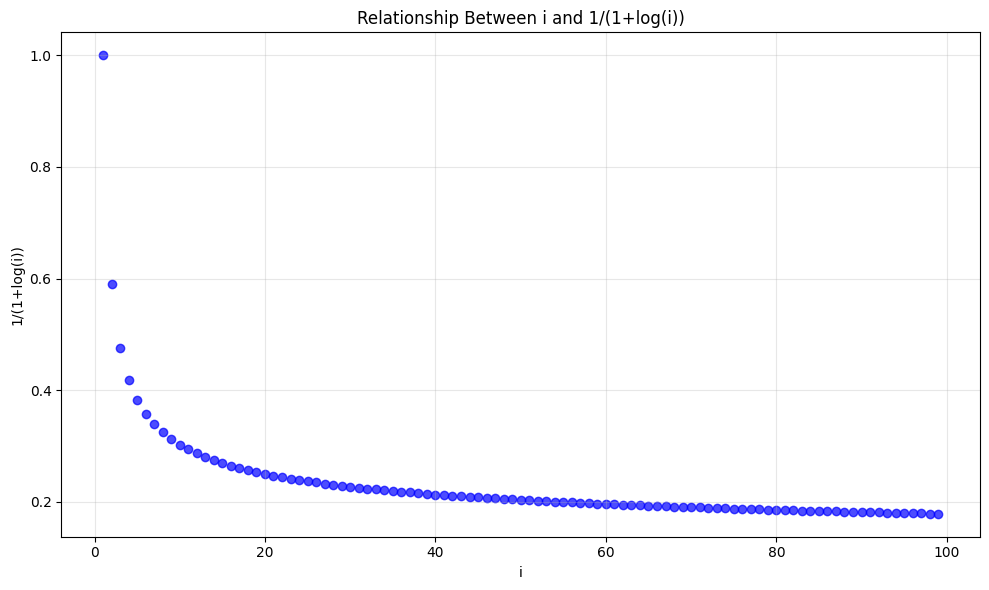

In [26]:
i_s = []
product = []
for i in range(1, 100):  # Starting from 1 to avoid log(0)
    i_s.append(i)
    product.append(1/(1+log(i)))

plt.figure(figsize=(10, 6))
plt.scatter(i_s, product, color='blue', alpha=0.7)
plt.title('Relationship Between i and 1/(1+log(i))')
plt.xlabel('i')
plt.ylabel('1/(1+log(i))')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#TODO: APPLY THIS RELATIONSHIP ON ALL COLUMNS EXPRESSING AN INVERSE RELATIONSHIP WITH MVI